# **Extracción de Caracteristicas COPIA TUTOR** 10-03-2026

referencia:


*   https://labex.io/es/tutorials/feature-extraction-with-scikit-learn-71129




In [ ]:
#ejemplo 1
from sklearn.feature_extraction import DictVectorizer

measurements = [
    {'city': 'Dubai', 'temperature': 33.},
    {'city': 'London', 'temperature': 12.},
    {'city': 'San Francisco', 'temperature': 18.},
]

vec = DictVectorizer()
features = vec.fit_transform(measurements).toarray()
feature_names = vec.get_feature_names_out()

print(features)
print(feature_names)

[[ 1.  0.  0. 33.]
 [ 0.  1.  0. 12.]
 [ 0.  0.  1. 18.]]
['city=Dubai' 'city=London' 'city=San Francisco' 'temperature']


In [ ]:
from sklearn.feature_extraction import FeatureHasher

movies = [
    {'category': ['thriller', 'drama'], 'year': 2003},
    {'category': ['animation', 'family'], 'year': 2011},
    {'year': 1974},
]

hasher = FeatureHasher(input_type='string')
hashed_features = hasher.transform(movies).toarray()

print(hashed_features)
hashed_features

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    'This is the first document.',
    'This is the second second document.',
    'And the third one.',
    'Is this the first document?',
]

vectorizer = CountVectorizer()
features = vectorizer.fit_transform(corpus).toarray()
feature_names = vectorizer.get_feature_names_out()

print(features)
print(feature_names)

[[0 1 1 1 0 0 1 0 1]
 [0 1 0 1 0 2 1 0 1]
 [1 0 0 0 1 0 1 1 0]
 [0 1 1 1 0 0 1 0 1]]
['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']


In [ ]:
from sklearn.datasets import load_iris
#from sklearn.feature_selection
from sklearn.decomposition import PCA

data = load_iris()
X = data.data
#y = data.target

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

print(X_reduced[:5])


[[-2.68412563  0.31939725]
 [-2.71414169 -0.17700123]
 [-2.88899057 -0.14494943]
 [-2.74534286 -0.31829898]
 [-2.72871654  0.32675451]]


In [ ]:
import pandas as pd

# 'data' is already loaded in the kernel from a previous cell (load_iris())
df_raw = pd.DataFrame(data=data.data, columns=data.feature_names)
df_raw['species'] = data.target

print(df_raw.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  


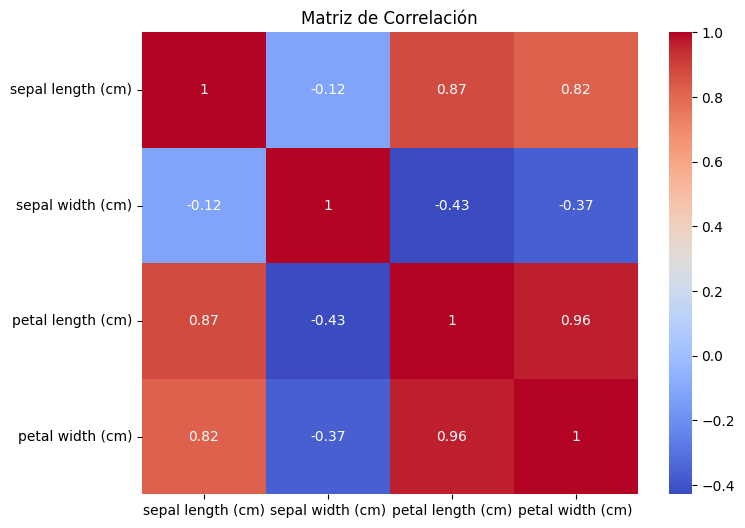

In [ ]:
df_corr_raw= df_raw.drop(columns=['species'])
corr_matrix_raw = df_corr_raw.corr()
print(corr_matrix_raw)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix_raw, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

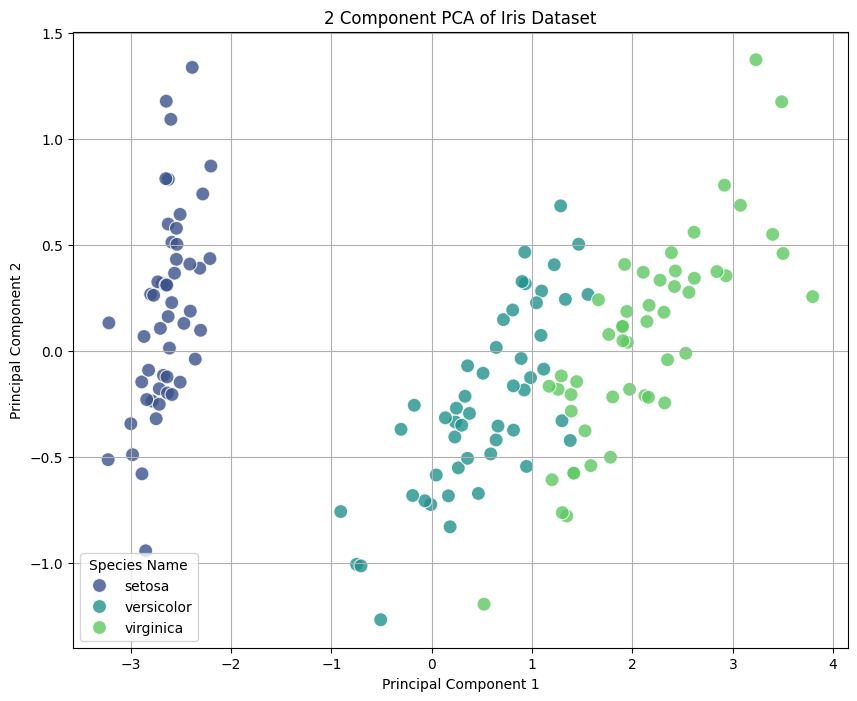

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming `data` (from load_iris) and `X_reduced` are available from previous cells.
# If `data` is not explicitly available, we can reload it.
from sklearn.datasets import load_iris
data = load_iris()

df_pca = pd.DataFrame(data=X_reduced, columns=['PrincipaComponent 1', 'Principal Component 2'])
df_pca['Species'] = data.target
df_pca['Species Name'] = df_pca['Species'].apply(lambda x: data.target_names[x])

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Species Name',
    data=df_pca,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('2 Component PCA of Iris Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()



                       Principal Component 1  Principal Component 2
Principal Component 1           1.000000e+00           2.108677e-14
Principal Component 2           2.108677e-14           1.000000e+00


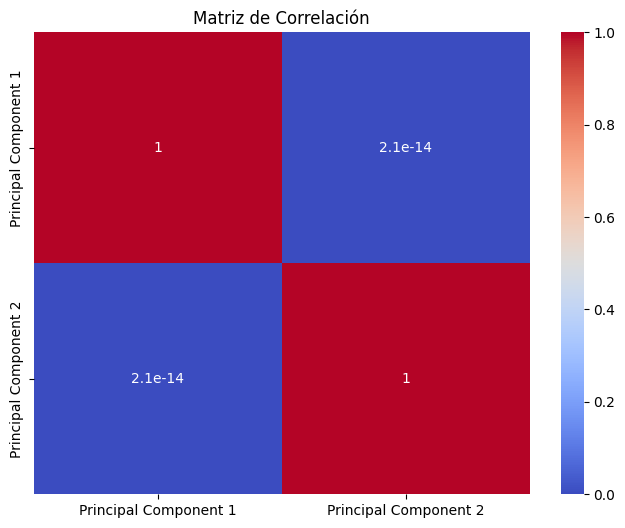

In [ ]:
dfa_corr = df_pca.drop(columns=['Species', 'Species Name'])
corr_matrix = dfa_corr.corr()
print(corr_matrix)
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()